In [ ]:
pip install -U langchain-community "unstructured[pdf]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.2/542.2 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
from unstructured.partition.pdf import partition_pdf

elements = partition_pdf(
    filename="research.pdf",
    strategy="hi_res",
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=True,
    infer_table_structure=True
)

for element in elements:
    print(type(element).__name__)
    print(element.text[:200])
    print("-" * 50)

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

Text
4
--------------------------------------------------
Text
2014
--------------------------------------------------
Text
1
--------------------------------------------------
Text
0
--------------------------------------------------
Header
2 n u J 0 1 ] L M . t a t s [ 1 v 1 6 6 2 . 6 0 4 1 : v i
--------------------------------------------------
Text
arX1V
--------------------------------------------------
Text
X
--------------------------------------------------
Text
r
--------------------------------------------------
Text
a
--------------------------------------------------
Title
Generative Adversarial Nets
--------------------------------------------------
Title
Ian J. Goodfellow, Jean Pouget-Abadie∗, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair†, Aaron Courville, Yoshua Bengio‡
--------------------------------------------------
NarrativeText
D´epartement d’informatique et de recherche op´erationnelle Universit´e de Montr´eal Montr´eal, QC H3C 3J7
--------------------

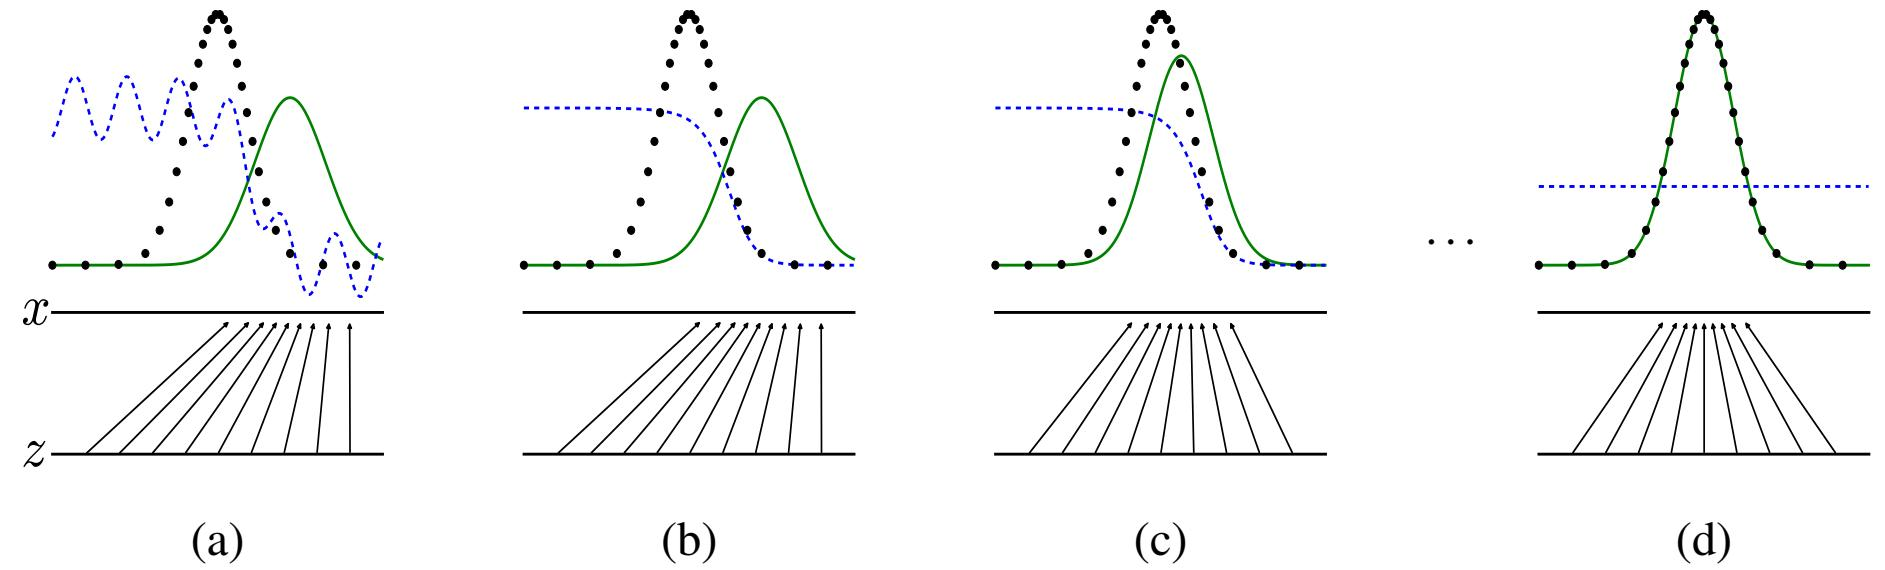

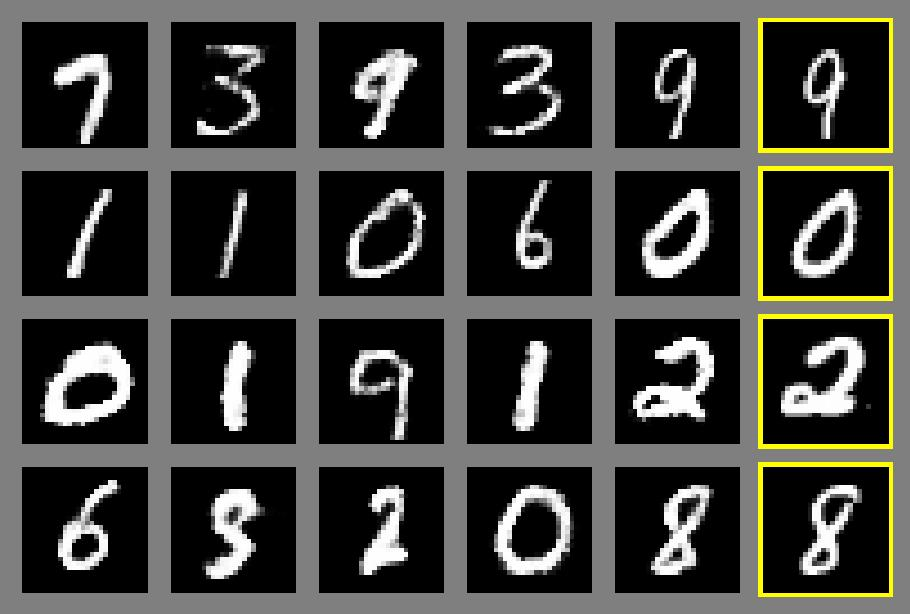

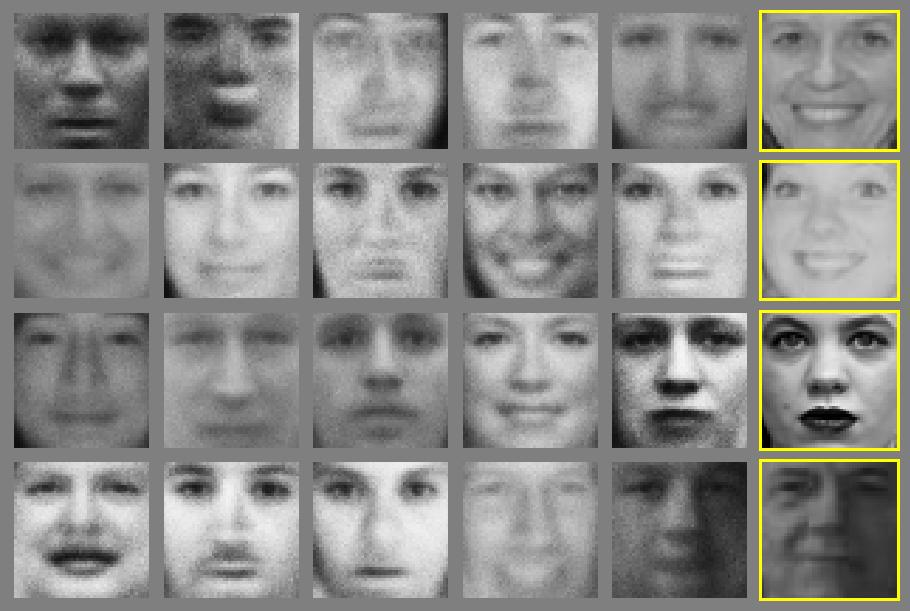

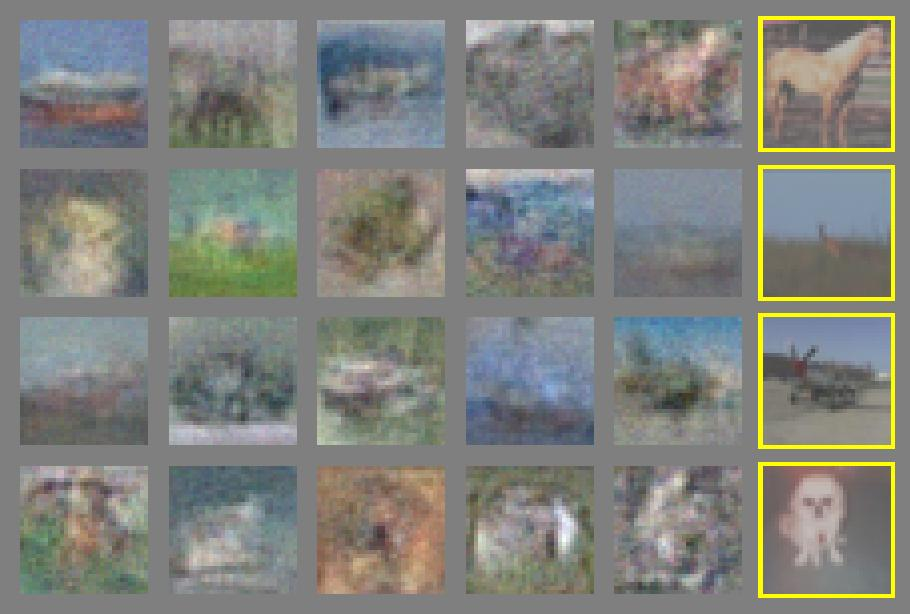

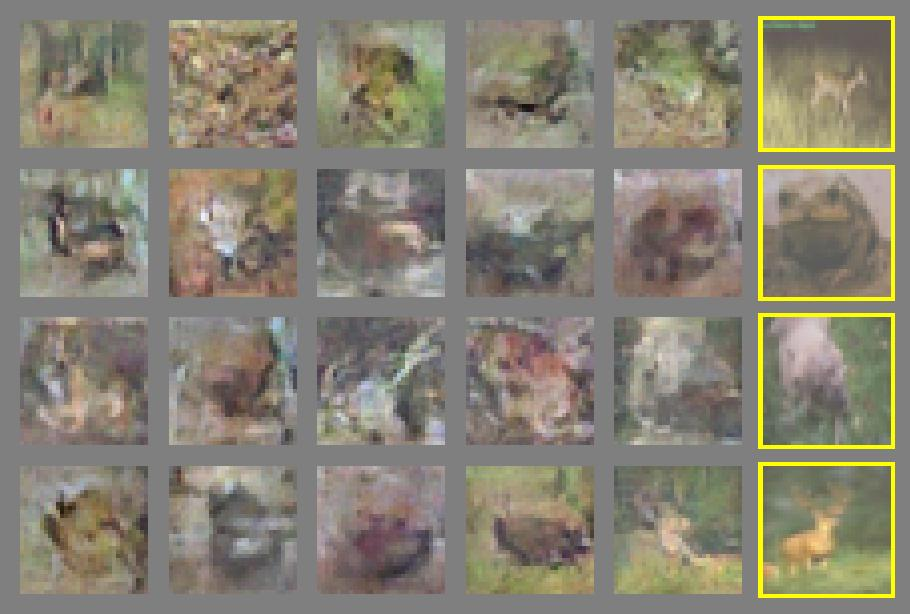

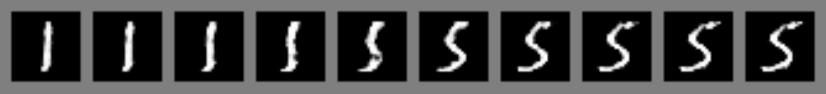

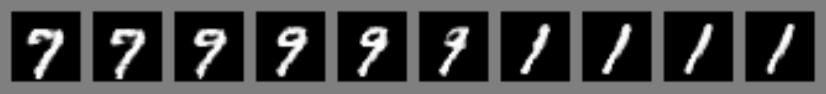

In [ ]:
import base64
from IPython.display import display, Image

for element in elements:
    if element.category == "Image":
        encoded = element.metadata.image_base64

        if encoded:
            image_bytes = base64.b64decode(encoded)
            display(Image(data=image_bytes))

In [ ]:
for element in elements:
    if element.category == "Table":
        print("Table text:")
        print(element.text)

        print("\nTable HTML:")
        print(element.metadata.text_as_html)

Table text:
Model MNIST TFD DBN [3] 138 ± 2 1909 ± 66 Stacked CAE [3] 121 ± 1.6 2110 ± 50 Deep GSN [6] 214 ± 1.1 1890 ± 29 Adversarial nets 225 ± 2 2057 ± 26

Table HTML:
<table><tbody><tr><td>Deep Adversarial</td><td>[6] nets</td><td>22542</td><td>| | 2057+</td><td>26</td></tr></tbody></table>
Table text:
graphical models graphical models autoencoders Adversarial models Training Inference needed during training. Inference needed during training. MCMC needed to approximate partition function gradient. Enforced tradeoff between mixing and power of reconstruction generation Synchronizing the discriminator with the generator. Helvetica. Inference Learned approximate inference Variational inference MCMC-based inference Learned approximate inference Sampling No difﬁculties Requires Markov chain Requires Markov chain No difﬁculties Not explicitly Not explicitly Intractable, may be Intractable, may be represented, may be approximated with approximated with approximated with approximated with 

In [ ]:
pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 17.1 MB/s eta 0:00:00


In [ ]:
sections = {}

current_section = "Unknown"

for element in elements:

    category = element.category
    text = element.text.strip()

    if not text:
        continue

    # A Title marks the beginning of a new section
    if category == "Title":
        current_section = text

        if current_section not in sections:
            sections[current_section] = []

    else:
        if current_section not in sections:
            sections[current_section] = []

        sections[current_section].append(element)

In [ ]:
for section, elements_in_section in sections.items():

    print("\n" + "=" * 60)
    print(section)
    print("=" * 60)

    for element in elements_in_section:
        print(
            element.category,
            "→",
            element.text[:100]
        )


Unknown
UncategorizedText → 4
UncategorizedText → 2014
UncategorizedText → 1
UncategorizedText → 0
Header → 2 n u J 0 1 ] L M . t a t s [ 1 v 1 6 6 2 . 6 0 4 1 : v i
UncategorizedText → arX1V
UncategorizedText → X
UncategorizedText → r
UncategorizedText → a

Generative Adversarial Nets

Ian J. Goodfellow, Jean Pouget-Abadie∗, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair†, Aaron Courville, Yoshua Bengio‡
NarrativeText → D´epartement d’informatique et de recherche op´erationnelle Universit´e de Montr´eal Montr´eal, QC H

Abstract
NarrativeText → We propose a new framework for estimating generative models via an adversar- ial process, in which w

1 Introduction
NarrativeText → The promise of deep learning is to discover rich, hierarchical models [2] that represent probability
NarrativeText → In the proposed adversarial nets framework, the generative model is pitted against an adversary: a d
UncategorizedText → ∗Jean Pouget-Abadie is visiting Universit´e de Montr´eal from Ecole

In [ ]:
from langchain_core.documents import Document

final_documents = []
image_elements = []
caption_documents = []

for section_name, section_elements in sections.items():

    text_buffer = []
    text_pages = []
    text_sources = []

    def flush_text_buffer():

        if not text_buffer:
            return

        combined_text = "\n\n".join(text_buffer)

        # Remove duplicate page numbers
        pages = [p for p in text_pages if p is not None]

        if pages:
            page_start = min(pages)
            page_end = max(pages)
        else:
            page_start = None
            page_end = None

        source = next(
            (s for s in text_sources if s is not None),
            None
        )

        chunks = text_splitter.create_documents(
            [combined_text],
            metadatas=[{
                "type": "text",
                "section": section_name,
                "page": page_start,
                "page_end": page_end,
                "source": source
            }]
        )

        final_documents.extend(chunks)

        text_buffer.clear()
        text_pages.clear()
        text_sources.clear()


    for element in section_elements:

        category = element.category
        text = element.text.strip()

        page = getattr(
            element.metadata,
            "page_number",
            None
        )

        source = getattr(
            element.metadata,
            "filename",
            None
        )


        # -----------------------------------------
        # TEXT
        # -----------------------------------------

        if category in [
            "NarrativeText",
            "Text",
            "ListItem"
        ]:

            if text:

                text_buffer.append(text)
                text_pages.append(page)
                text_sources.append(source)


        # -----------------------------------------
        # FIGURE CAPTION
        # -----------------------------------------

        elif category == "FigureCaption":

            # Flush preceding text
            flush_text_buffer()

            if text:

                caption_documents.append(
                    Document(
                        page_content=text,
                        metadata={
                            "type": "figure_caption",
                            "section": section_name,
                            "page": page,
                            "source": source
                        }
                    )
                )


        # -----------------------------------------
        # TABLE
        # -----------------------------------------

        elif category == "Table":

            flush_text_buffer()

            table_html = getattr(
                element.metadata,
                "text_as_html",
                None
            )

            caption_or_text = table_html or text

            if caption_or_text:

                final_documents.append(
                    Document(
                        page_content=caption_or_text,
                        metadata={
                            "type": "table",
                            "section": section_name,
                            "page": page,
                            "source": source
                        }
                    )
                )


        # -----------------------------------------
        # IMAGE
        # -----------------------------------------

        elif category == "Image":

            flush_text_buffer()

            image_base64 = getattr(
                element.metadata,
                "image_base64",
                None
            )

            image_elements.append({
                "section": section_name,
                "page": page,
                "source": source,
                "image_base64": image_base64
            })


    # -----------------------------------------
    # FLUSH TEXT AT END OF SECTION
    # -----------------------------------------

    flush_text_buffer()


print("Text documents :", len(final_documents))
print("Images          :", len(image_elements))
print("Captions        :", len(caption_documents))

Text documents : 48
Images          : 3
Captions        : 3


In [ ]:
image_elements

[{'section': '3 Adversarial nets',
  'page': 3,
  'source': 'research.pdf',
  'image_base64': '...'},
 {'section': '5 Experiments',
  'page': 7,
  'source': 'research.pdf',
  'image_base64': '/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCABeAzoDASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3

In [ ]:
final_documents

[Document(metadata={'type': 'text', 'section': 'Ian J. Goodfellow, Jean Pouget-Abadie∗, Mehdi Mirza, Bing Xu, David Warde-Farley, Sherjil Ozair†, Aaron Courville, Yoshua Bengio‡'}, page_content='D´epartement d’informatique et de recherche op´erationnelle Universit´e de Montr´eal Montr´eal, QC H3C 3J7'),
 Document(metadata={'type': 'text', 'section': 'Abstract'}, page_content='We propose a new framework for estimating generative models via an adversar- ial process, in which we simultaneously train two models: a generative model G that captures the data distribution, and a discriminative model D that estimates the probability that a sample came from the training data rather than G. The train- ing procedure for G is to maximize the probability of D making a mistake. This framework corresponds to a minimax two-player game. In the space of arbitrary functions G and D, a unique solution exists, with G recovering the training data distribution and D equal to 1 2 everywhere. In the case where 

In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

model_name = "Qwen/Qwen2-VL-2B-Instruct"

# Load processor
processor = AutoProcessor.from_pretrained(model_name)

# Load model
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("Qwen2-VL model and processor loaded successfully")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Qwen2-VL model and processor loaded successfully


In [ ]:
import base64
import io

from PIL import Image
from qwen_vl_utils import process_vision_info
from langchain_core.documents import Document


qwen_documents = []


prompt = """
You are analyzing an image extracted from a research paper.

The image is part of the research paper currently being processed.

Your task is to describe and interpret the figure accurately.

Analyze the figure carefully, including multiple panels if present.

For each panel:

1. Identify the panel label.
2. Describe the visible curves, distributions, diagrams,
   objects, or components.
3. Identify readable labels, text, equations, and axes.
4. Describe colors and line styles when clearly visible.
5. Describe arrows, connections, and directions.
6. Describe how the panels differ or change.
7. Explain the research concept represented by the figure,
   using the visual evidence and the paper context.

IMPORTANT:
- Do not invent numerical values.
- Do not invent labels.
- Do not invent components.
- Do not claim something is visible if it cannot be seen.
- If text is unreadable, say "unclear".
- Distinguish visible observations from interpretation.
- If the figure contains four panels, analyze all four.
- Keep the description focused on information useful for
  answering questions about the research paper.

Return the result in this structure:

Figure Type:
...

Panel (a):
...

Panel (b):
...

Panel (c):
...

Panel (d):
...

Visible Labels:
...

Visible Curves / Components:
...

Arrows / Relationships:
...

Overall Figure Interpretation:
...
"""


for i, image in enumerate(image_elements):

    if not image["image_base64"]:
        continue


    # -----------------------------------------
    # Decode image
    # -----------------------------------------

    image_bytes = base64.b64decode(
        image["image_base64"]
    )

    pil_image = Image.open(
        io.BytesIO(image_bytes)
    ).convert("RGB")


    # -----------------------------------------
    # Create Qwen message
    # -----------------------------------------

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": pil_image
                },
                {
                    "type": "text",
                    "text": prompt
                }
            ]
        }
    ]


    # -----------------------------------------
    # Apply chat template
    # -----------------------------------------

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )


    # -----------------------------------------
    # Process visual inputs
    # -----------------------------------------

    image_inputs, video_inputs = process_vision_info(
        messages
    )


    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(model.device)


    # -----------------------------------------
    # Generate description
    # -----------------------------------------

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=700
    )


    # -----------------------------------------
    # Remove input tokens
    # -----------------------------------------

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]


    # -----------------------------------------
    # Decode
    # -----------------------------------------

    description = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]


    # -----------------------------------------
    # Create LangChain Document
    # -----------------------------------------

    qwen_documents.append(
        Document(
            page_content=description,
            metadata={
                "type": "image",
                "section": image["section"],
                "page": image["page"],
                "source": image["source"],
                "image_id": i,
                "description_source": "Qwen2-VL"
            }
        )
    )


print("Qwen image documents:", len(qwen_documents))

Qwen image documents: 3


In [ ]:
all_documents = final_documents + qwen_documents

print("Total documents:", len(all_documents))

Total documents: 51


In [ ]:
!pip install -U langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.42.1
    Uninstalling opentelemetry-api-1.42.1:
      Successfully uninstalled opentelemetry-api-1.42.1
  Attempting

In [ ]:
import os
import shutil

chroma_path = os.path.abspath("./chroma_db")

# Remove old/incomplete Chroma database
if os.path.exists(chroma_path):
    shutil.rmtree(chroma_path)

# Recreate directory
os.makedirs(chroma_path, exist_ok=True)

print("Chroma path:", chroma_path)
print("Exists:", os.path.exists(chroma_path))
print("Writable:", os.access(chroma_path, os.W_OK))

Chroma path: /content/chroma_db
Exists: True
Writable: True


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5"
)

vectorstore = Chroma.from_documents(
    documents=all_documents,
    embedding=embeddings,
    collection_name="research_papers",
    persist_directory=chroma_path,
    collection_metadata={
        "hnsw:space": "cosine"
    }
)

print("Documents stored:", len(all_documents))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Documents stored: 51


In [ ]:
import pickle

with open("elements.pkl", "wb") as f:
    pickle.dump(elements, f)
with open("sections.pkl", "wb") as f:
    pickle.dump(sections, f)
with open("final_documents.pkl", "wb") as f:
    pickle.dump(final_documents, f)
with open("qwen_documents.pkl", "wb") as f:
    pickle.dump(qwen_documents, f)

In [ ]:
!pip install -U rank_bm25

In [ ]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(
    all_documents
)

bm25_retriever.k = 10

/tmp/ipykernel_5690/1791271874.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


In [ ]:
vector_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 10}
)

In [ ]:
def hybrid_retrieve(query, k=5, retrieval_k=10):

    # -------------------------
    # BM25
    # -------------------------
    bm25_retriever.k = retrieval_k

    bm25_docs = bm25_retriever.invoke(query)

    # -------------------------
    # Cosine / Chroma
    # -------------------------
    vector_docs = vectorstore.similarity_search(
        query,
        k=retrieval_k
    )

    # -------------------------
    # Reciprocal Rank Fusion
    # -------------------------
    rrf_scores = {}
    documents = {}

    rrf_k = 60

    # BM25 ranking
    for rank, doc in enumerate(bm25_docs, start=1):

        doc_id = hash(doc.page_content)

        rrf_scores[doc_id] = (
            rrf_scores.get(doc_id, 0)
            + 1 / (rrf_k + rank)
        )

        documents[doc_id] = doc

    # Vector ranking
    for rank, doc in enumerate(vector_docs, start=1):

        doc_id = hash(doc.page_content)

        rrf_scores[doc_id] = (
            rrf_scores.get(doc_id, 0)
            + 1 / (rrf_k + rank)
        )

        documents[doc_id] = doc

    # -------------------------
    # Sort by RRF score
    # -------------------------
    ranked_docs = sorted(
        rrf_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    results = []

    for doc_id, score in ranked_docs[:k]:

        doc = documents[doc_id]

        results.append({
            "document": doc,
            "rrf_score": score
        })

    return results

In [ ]:

test_queries = [

    # 1. Core concept
    "What are the roles of the generator G and discriminator D in adversarial nets?",

    # 2. Mathematical objective
    "What is the value function V(G,D) in the two-player minimax game?",

    # 3. Training algorithm
    "What steps are performed in Algorithm 1 for minibatch stochastic gradient descent?",

    # 4. Generator objective
    "Why does the paper suggest maximizing log D(G(z)) instead of minimizing log(1-D(G(z)))?",

    # 5. Optimal discriminator
    "What is the optimal discriminator D* for a fixed generator G?",

    # 6. Global optimum
    "Under what condition does the global minimum of the virtual training criterion occur?",

    # 7. Figure 1
    "What does Figure 1 illustrate about the training process of generative adversarial nets?",

    # 8. Figure 1 distribution
    "How does the generator distribution pg change during the training process shown in Figure 1?",

    # 9. Datasets
    "Which datasets were used to evaluate the adversarial nets in the experiments?",

    # 10. Experimental architecture
    "What activation functions and regularization techniques were used for the generator and discriminator?",

    # 11. Evaluation
    "How was the probability of test set data under pg estimated?",

    # 12. Figure 2
    "What does Figure 2 show about the samples generated by the trained generator?",

    # 13. Figure 3
    "What does Figure 3 demonstrate using interpolation in z space?",

    # 14. Advantages
    "What computational advantages does the adversarial nets framework have?",

    # 15. Limitation
    "What is the main synchronization problem between G and D during GAN training?"
]


# ============================================
# RUN TESTS
# ============================================

for query_number, query in enumerate(test_queries, start=1):

    print("\n")
    print("#" * 100)
    print(f"QUERY {query_number}")
    print("#" * 100)

    print("\nQuestion:")
    print(query)

    # Hybrid retrieval
    results = hybrid_retrieve(
        query=query,
        k=5,
        retrieval_k=10
    )

    print("\nRetrieved Results:")

    for rank, result in enumerate(results, start=1):

        doc = result["document"]

        print("\n" + "-" * 90)
        print(f"RESULT {rank}")
        print("-" * 90)

        print("RRF Score :", round(result["rrf_score"], 6))
        print("Type      :", doc.metadata.get("type"))
        print("Section   :", doc.metadata.get("section"))
        print("Page      :", doc.metadata.get("page"))
        print("Source    :", doc.metadata.get("source"))

        print("\nContent:")
        print(doc.page_content[:1000])

    print("\n")



####################################################################################################
QUERY 1
####################################################################################################

Question:
What are the roles of the generator G and discriminator D in adversarial nets?

Retrieved Results:

------------------------------------------------------------------------------------------
RESULT 1
------------------------------------------------------------------------------------------
RRF Score : 0.048916
Type      : text
Section   : 5 Experiments
Page      : 6
Source    : research.pdf

Content:
We trained adversarial nets an a range of datasets including MNIST[23], the Toronto Face Database (TFD) [28], and CIFAR-10 [21]. The generator nets used a mixture of rectiﬁer linear activations [19, 9] and sigmoid activations, while the discriminator net used maxout [10] activations. Dropout [17] was applied in training the discriminator net. While our theoretical framew

In [ ]:
from google.colab import userdata
groq_key = userdata.get('GROQ_API_KEY')

In [ ]:
import requests, os
resp = requests.get(
    "https://api.groq.com/openai/v1/models",
    headers={"Authorization": f"Bearer {os.environ['GROQ_API_KEY']}"}
)
for m in resp.json()["data"]:
    print(m["id"])

canopylabs/orpheus-arabic-saudi
openai/gpt-oss-safeguard-20b
openai/gpt-oss-120b
qwen/qwen3.8-27b
allam-2-7b
openai/gpt-oss-20b
whisper-large-v3-turbo
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-prompt-guard-2-22m
whisper-large-v3
canopylabs/orpheus-v1-english


In [ ]:
from langchain_groq import ChatGroq
import os
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
llm = ChatGroq(model="openai/gpt-oss-120b", api_key=os.environ["GROQ_API_KEY"], temperature=0)


In [ ]:
def research_retriever(question):

    results = hybrid_retrieve(
        question,
        k=10,
        retrieval_k=20
    )

    return [
        result["document"]
        for result in results
    ]

In [ ]:
def format_context(docs):

    context_parts = []

    for i, doc in enumerate(docs, start=1):

        metadata = doc.metadata

        context_parts.append(
            f"""
SOURCE {i}

Type: {metadata.get("type", "unknown")}
Section: {metadata.get("section", "unknown")}
Page: {metadata.get("page", "unknown")}
Page End: {metadata.get("page_end", "unknown")}
Source: {metadata.get("source", "unknown")}

Content:
{doc.page_content}
"""
        )

    return "\n\n".join(context_parts)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_template("""
You are a research assistant answering questions about a research paper.

Answer the user's question using ONLY the retrieved context.

Rules:

1. Use the retrieved context as the primary source of truth.
2. Do not invent facts that are not supported by the context.
3. If the context is insufficient, say:
   "The retrieved context does not provide enough information to answer this."
4. Explain technical concepts clearly.
5. Preserve equations, mathematical notation, variables,
   and terminology when relevant.
6. If information comes from a figure or table, mention it.
7. Combine multiple sources when necessary.
8. Do not mention BM25, vector search, embeddings, RRF,
   or the internal retrieval process unless explicitly asked.
9. Do not use outside knowledge to fill gaps.

Retrieved Context:
------------------
{context}
------------------

Question:
{question}

Answer:
""")

In [ ]:
from langchain_core.runnables import (
    RunnableLambda,
    RunnablePassthrough
)


# 1. Convert model response into plain text
def extract_text(content):

    if isinstance(content, list):
        return "\n".join(
            item["text"]
            for item in content
            if isinstance(item, dict)
            and item.get("type") == "text"
        )

    return content


# 2. Prepare input
prepare_input = RunnableLambda(
    lambda question: {
        "question": question
    }
)


# 3. Retrieve documents using BM25 + Vector + RRF
add_docs = RunnablePassthrough.assign(
    docs=RunnableLambda(
        lambda x: research_retriever(
            x["question"]
        )
    )
)


# 4. Convert retrieved documents into context
add_context = RunnablePassthrough.assign(
    context=RunnableLambda(
        lambda x: format_context(
            x["docs"]
        )
    )
)


# 5. Send context + question to the LLM
add_response = RunnablePassthrough.assign(
    response=(
        {
            "context": RunnableLambda(
                lambda x: x["context"]
            ),
            "question": RunnableLambda(
                lambda x: x["question"]
            )
        }
        | rag_prompt
        | llm
    )
)


# 6. Complete RAG chain
rag_chain = (
    prepare_input
    | add_docs
    | add_context
    | add_response
    | RunnableLambda(
        lambda x: {
            "answer": extract_text(
                x["response"].content
            ),
            "sources": x["docs"]
        }
    )
)


print("RAG chain created successfully!")

RAG chain created successfully!


In [ ]:
questions = [
    "What is the main idea of the paper?",
    "What problem does the paper try to solve?",
    "What is the proposed methodology?",
    "What are the main components of the proposed model?",
    "What is the role of the generator?",
    "What is the role of the discriminator?",
    "What is the minimax objective?",
    "What is the global optimum of the minimax game?",
    "What does Figure 1 represent?",
    "What does Figure 2 show?",
    "What datasets were used in the experiments?",
    "What are the main experimental results?",
    "What are the advantages of the proposed approach?",
    "What are the limitations mentioned by the authors?"
]

for question in questions:
    result = rag_chain.invoke(question)

    print("\n" + "=" * 80)
    print("QUESTION:", question)
    print("=" * 80)
    print(result["answer"])


QUESTION: What is the main idea of the paper?
The paper proposes an **adversarial‑nets framework** in which a **generative model (G)** and a **discriminative model (D)** are trained together in a two‑player game.  
- The discriminator learns to tell whether a sample comes from the true data distribution \(p_{\text{data}}\) or from the generator’s distribution \(p_{g}\).  
- The generator tries to produce samples that fool the discriminator, i.e., to make \(p_{g}\) indistinguishable from \(p_{\text{data}}\).  

Because the two networks are optimized simultaneously, the competition drives both models to improve until the generator perfectly replicates the data‑generating process (the global optimum \(p_{g}=p_{\text{data}}\) is shown via the Jensen–Shannon divergence in Section 4.1).  

A key contribution is that **no Markov chains or explicit inference procedures are required** during training or sample generation; learning relies solely on back‑propagation of gradients (Section 6). Thi